E)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MultipleLocator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import _LinearRegression
import OLS

import seaborn as sns

In [2]:
def Runge_func(x):
    return 1.0/(1 + 25*x**2)

In [3]:
np.random.seed(2025)

n = 1000
x = np.linspace(-1, 1, n)

std = 0.1
y = Runge_func(x) + np.random.normal(0, std, size=n)

degree = 1

x = x.reshape(-1, 1)
y = y.reshape(-1,1)

X = PolynomialFeatures(degree, include_bias=False).fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train_s = scaler_y.transform(y_train)
y_test_s = scaler_y.transform(y_test)

In [78]:
# Setup FFNN 

np.random.seed(2025)

num_input_feats = 1 # Number of input features
num_output_feats = 1 # Number og output features

batch_size = 100
epochs = 200

reg_params = np.logspace(-6, -1, 6)
regs = ["L1", "L2"]

MSE_test_regparams_regs_matrix = np.zeros([len(reg_params), len(regs)])

for i in range(len(reg_params)):
    for j in range(len(regs)):

        scheduler = Adam(0.001)
        ffnn = NeuralNetwork(num_input_feats, 
                            num_output_feats,
                            [100, 100],
                            [sigmoid, sigmoid, id_func], 
                            [sigmoid_der, sigmoid_der, id_func_der],
                            scheduler, 
                            mse, 
                            mse_der,
                            regularization = regs[j], reg_param=reg_params[i],
                            seed=2025
                            )

        #Train
        ffnn.train(X_train_s.reshape(-1,1), y_train_s, batch_size, epochs)

        test_pred = ffnn.predict(X_test_s.reshape(-1,1))

        test_pred = scaler_y.inverse_transform(test_pred)

        MSE_test_regparams_regs_matrix[i, j] = mean_squared_error(test_pred, y_test)

    print(i)

0
1
2
3
4
5


In [84]:
MSE_test_regparams_regs_matrix

array([[0.00884914, 0.00883809],
       [0.00889913, 0.00889353],
       [0.0089129 , 0.00888735],
       [0.00990768, 0.00974557],
       [0.01738935, 0.01768256],
       [0.0896484 , 0.0890988 ]])

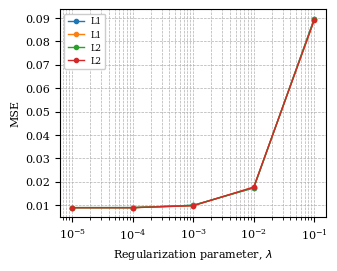

In [86]:
MM_TO_INCH = 1/25.4

matplotlib.rc("text", usetex=False)
plt.rc('lines', linewidth=1.0)
plt.rc("figure", autolayout=True)
plt.rc("legend", fontsize=6)
plt.rc("font", family="serif", size=8)
plt.figure(figsize=(86.78*MM_TO_INCH, 70*MM_TO_INCH))
# # plt.ticklabel_format(axis = "y", style="sci")
# # plt.gca().xaxis.set_major_locator(MultipleLocator(base=1, offset=1))   # Configure the markers on the x axis
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.semilogx(reg_params[1:], MSE_test_regparams_regs_matrix[1:], ".-", label="L1")
plt.semilogx(reg_params[1:], MSE_test_regparams_regs_matrix[1:], ".-", label="L2")

plt.xlabel(f"Regularization parameter, $\lambda$")
plt.ylabel("MSE")
# plt.title(f"MSE for test prediction, FFNN [100, 100], data std. {std}")
plt.legend().get_frame().set_alpha(1.0) # Add solid background (non see thru) to legend box
# plt.savefig("plot_MSE_batchsize_FFNN_100_100.pdf", bbox_inches="tight")
plt.show()
plt.close()

0.008841106509079917


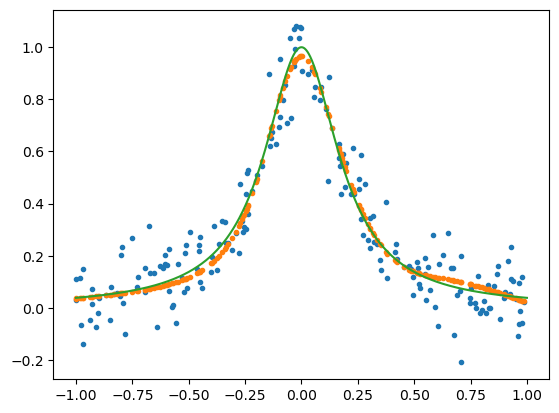

In [14]:
XX_train = X_train[:, 0] # The x^1 values
XX_test = X_test[:, 0] # The x^1 values

sorted_indices_XX_train = np.argsort(XX_train)
sorted_indices_XX_test = np.argsort(XX_test)

XX_train_sorted = XX_train[sorted_indices_XX_train]
XX_test_sorted = XX_test[sorted_indices_XX_test]

y_train_sorted = y_train[sorted_indices_XX_train]
y_test_sorted = y_test[sorted_indices_XX_test]

test_pred_sorted = test_pred[sorted_indices_XX_test]
print(mean_squared_error(test_pred, y_test))

plt.plot(XX_test_sorted, y_test_sorted, '.')
plt.plot(XX_test_sorted, test_pred_sorted, '.')
plt.plot(x, Runge_func(x), "-")